In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from heapq import heappush, heappop
from collections import deque
from copy import deepcopy

In [2]:
def exp_time(rng, rate):
    return float(rng.exponential(1 / rate))


def run_simulation(sim_time=1000, arrival_rate=2.0, entry_mu=8.0, parking_mu=0.8, exit_mu=6.0,
                   parking_queue_capacity=15, p_return_to_parking=0.15,
                   min_active=1, max_active=5, initial_active=3,
                   connect_rate=0.8, disconnect_rate=0.4, seed=42):
    rng = np.random.default_rng(seed)
    nodes = [
        {"name": "Въездной шлагбаум", "mu": entry_mu, "capacity": 25, "active": 1, "min_active": 1, "max_active": 1},
        {"name": "Парковочное место", "mu": parking_mu, "capacity": parking_queue_capacity, "active": initial_active, "min_active": min_active, "max_active": max_active},
        {"name": "Выездной терминал", "mu": exit_mu, "capacity": 25, "active": 1, "min_active": 1, "max_active": 1},
    ]
    for node in nodes:
        node["queue"] = deque()
        node["busy"] = 0
        node["queue_area"] = 0.0
        node["active_area"] = 0.0
        node["busy_area"] = 0.0
        node["last_time"] = 0.0
        node["wait_sum"] = 0.0
        node["visits"] = 0
        node["lost"] = 0
    events = []
    event_id = 0
    cars_started = 0
    completed = 0
    lost = 0
    sojourn_sum = 0.0
    active_history = []
    def schedule(time, event_type, node_id=None, car=None):
        nonlocal event_id
        if time <= sim_time:
            heappush(events, (time, event_id, event_type, node_id, car))
            event_id += 1
    def update_areas(time):
        for node in nodes:
            dt = time - node["last_time"]
            if dt > 0:
                node["queue_area"] += dt * len(node["queue"])
                node["active_area"] += dt * node["active"]
                node["busy_area"] += dt * node["busy"]
                node["last_time"] = time
    def start_service(node_id, time):
        node = nodes[node_id]
        while node["queue"] and node["busy"] < node["active"]:
            car = node["queue"].popleft()
            node["wait_sum"] += time - car["node_arrival"]
            node["visits"] += 1
            node["busy"] += 1
            schedule(time + exp_time(rng, node["mu"]), "complete", node_id, car)
    def arrive_to_node(node_id, car, time):
        nonlocal lost
        node = nodes[node_id]
        if not node["queue"] and node["busy"] < node["active"]:
            node["visits"] += 1
            node["busy"] += 1
            schedule(time + exp_time(rng, node["mu"]), "complete", node_id, car)
        elif len(node["queue"]) < node["capacity"]:
            car["node_arrival"] = time
            node["queue"].append(car)
        else:
            node["lost"] += 1
            lost += 1
    schedule(exp_time(rng, arrival_rate), "external_arrival")
    schedule(exp_time(rng, connect_rate), "connect", 1)
    schedule(exp_time(rng, disconnect_rate), "disconnect", 1)
    while events:
        time, _, event_type, node_id, car = heappop(events)
        update_areas(time)
        if event_type == "external_arrival":
            cars_started += 1
            new_car = {"id": cars_started, "start": time, "node_arrival": time}
            arrive_to_node(0, new_car, time)
            schedule(time + exp_time(rng, arrival_rate), "external_arrival")
        elif event_type == "complete":
            node = nodes[node_id]
            node["busy"] -= 1
            if node_id == 0:
                car["node_arrival"] = time
                arrive_to_node(1, car, time)
            elif node_id == 1:
                if rng.random() < p_return_to_parking:
                    car["node_arrival"] = time
                    arrive_to_node(1, car, time)
                else:
                    car["node_arrival"] = time
                    arrive_to_node(2, car, time)
            else:
                completed += 1
                sojourn_sum += time - car["start"]
            start_service(node_id, time)
        elif event_type == "connect":
            node = nodes[node_id]
            if node["active"] < node["max_active"]:
                node["active"] += 1
            active_history.append((time, node["active"]))
            start_service(node_id, time)
            schedule(time + exp_time(rng, connect_rate), "connect", node_id)
        elif event_type == "disconnect":
            node = nodes[node_id]
            if node["active"] > node["min_active"] and node["active"] > node["busy"]:
                node["active"] -= 1
            active_history.append((time, node["active"]))
            schedule(time + exp_time(rng, disconnect_rate), "disconnect", node_id)
    update_areas(sim_time)
    parking = nodes[1]
    network_queue_area = sum(node["queue_area"] for node in nodes)
    network_wait_sum = sum(node["wait_sum"] for node in nodes)
    network_visits = sum(node["visits"] for node in nodes)
    return {
        "arrival_rate": arrival_rate,
        "parking_mu": parking_mu,
        "connect_rate": connect_rate,
        "disconnect_rate": disconnect_rate,
        "arrived": cars_started,
        "completed": completed,
        "lost": lost,
        "loss_probability": lost / cars_started if cars_started else np.nan,
        "avg_sojourn": sojourn_sum / completed if completed else np.nan,
        "avg_wait": network_wait_sum / network_visits if network_visits else np.nan,
        "avg_queue": network_queue_area / sim_time,
        "avg_parking_queue": parking["queue_area"] / sim_time,
        "avg_active": parking["active_area"] / sim_time,
        "parking_utilization": parking["busy_area"] / parking["active_area"] if parking["active_area"] > 0 else np.nan,
        "active_history": active_history,
        "node_stats": [{"node": node["name"], "avg_queue": node["queue_area"] / sim_time, "avg_active": node["active_area"] / sim_time, "utilization": node["busy_area"] / node["active_area"] if node["active_area"] > 0 else np.nan, "avg_wait": node["wait_sum"] / node["visits"] if node["visits"] else np.nan, "visits": node["visits"], "lost": node["lost"]} for node in nodes]
    }


def run_many(repeats=12, **params):
    rows = []
    for i in range(repeats):
        result = run_simulation(seed=1000 + i, **params)
        rows.append({k: v for k, v in result.items() if k not in {"active_history", "node_stats"}})
    return pd.DataFrame(rows).mean(numeric_only=True).to_dict()

In [3]:
base_params = {
    "sim_time": 1000,
    "arrival_rate": 2.0,
    "entry_mu": 8.0,
    "parking_mu": 0.8,
    "exit_mu": 6.0,
    "parking_queue_capacity": 15,
    "p_return_to_parking": 0.15,
    "min_active": 1,
    "max_active": 5,
    "initial_active": 3,
    "connect_rate": 0.8,
    "disconnect_rate": 0.4,
}

base_result = run_simulation(**base_params, seed=42)
base_many = run_many(**base_params)
pd.DataFrame([base_many])

,arrival_rate,parking_mu,connect_rate,disconnect_rate,arrived,completed,lost,loss_probability,avg_sojourn,avg_wait,avg_queue,avg_parking_queue,avg_active,parking_utilization
0,2.0,0.8,0.8,0.4,2007.666667,2001.166667,0.0,0.0,2.167045,0.126723,0.810811,0.553124,4.535063,0.650777


In [4]:
pd.DataFrame(base_result["node_stats"])

,node,avg_queue,avg_active,utilization,avg_wait,visits,lost
0,Въездной шлагбаум,0.074136,1.000000,0.243434,0.036902,2009,0
1,Парковочное место,0.523401,4.542525,0.656484,0.222009,2356,0
2,Выездной терминал,0.181106,1.000000,0.337644,0.090417,2003,0


In [5]:
scenarios = [
    ("частые отключения", 0.25, 1.00),
    ("отключения чаще подключений", 0.40, 0.80),
    ("равная динамика", 0.60, 0.60),
    ("подключения чаще отключений", 0.80, 0.40),
    ("почти всегда много мест", 1.20, 0.25),
]

scenario_rows = []
for name, connect_rate, disconnect_rate in scenarios:
    params = deepcopy(base_params)
    params["connect_rate"] = connect_rate
    params["disconnect_rate"] = disconnect_rate
    result = run_many(**params)
    result["scenario"] = name
    scenario_rows.append(result)

scenario_df = pd.DataFrame(scenario_rows)[["scenario", "connect_rate", "disconnect_rate", "avg_active", "avg_sojourn", "avg_wait", "avg_parking_queue", "avg_queue", "loss_probability", "parking_utilization"]]
scenario_df

,scenario,connect_rate,disconnect_rate,avg_active,avg_sojourn,avg_wait,avg_parking_queue,avg_queue,loss_probability,parking_utilization
0,частые отключения,0.25,1.00,3.231897,3.700158,0.616489,3.585179,3.859495,0.018386,0.888525
1,отключения чаще подключений,0.40,0.80,3.616627,2.816823,0.333571,1.845358,2.121001,0.003350,0.810333
2,равная динамика,0.60,0.60,4.076357,2.345699,0.185480,0.928591,1.180975,0.000657,0.718674
3,подключения чаще отключений,0.80,0.40,4.535063,2.167045,0.126723,0.553124,0.810811,0.000000,0.650777
4,почти всегда много мест,1.20,0.25,4.821438,2.056668,0.095497,0.356721,0.608770,0.000042,0.608020


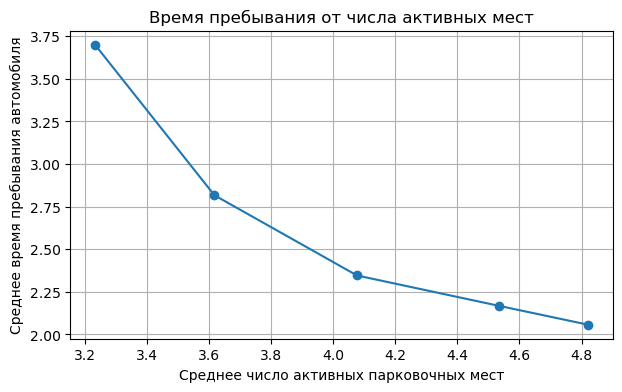

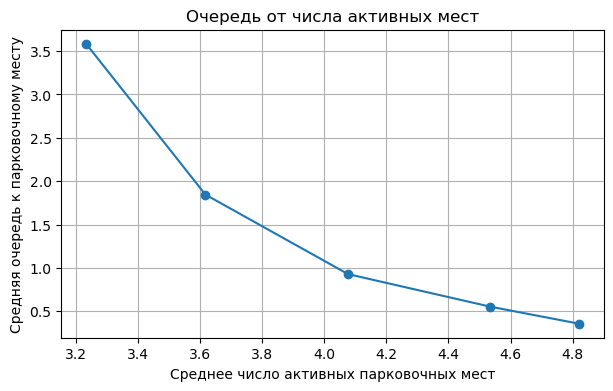

In [6]:
active_sorted = scenario_df.sort_values("avg_active")
plt.figure(figsize=(7, 4))
plt.plot(active_sorted["avg_active"], active_sorted["avg_sojourn"], marker="o")
plt.xlabel("Среднее число активных парковочных мест")
plt.ylabel("Среднее время пребывания автомобиля")
plt.title("Время пребывания от числа активных мест")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(active_sorted["avg_active"], active_sorted["avg_parking_queue"], marker="o")
plt.xlabel("Среднее число активных парковочных мест")
plt.ylabel("Средняя очередь к парковочному месту")
plt.title("Очередь от числа активных мест")
plt.grid(True)
plt.show()

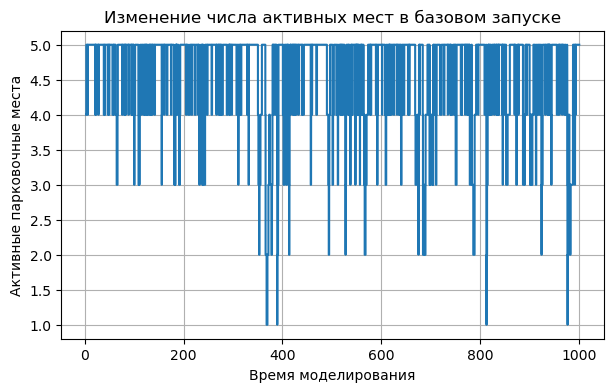

In [7]:
hist = np.array(base_result["active_history"])
plt.figure(figsize=(7, 4))
if len(hist) > 0:
    plt.step(hist[:, 0], hist[:, 1], where="post")
plt.xlabel("Время моделирования")
plt.ylabel("Активные парковочные места")
plt.title("Изменение числа активных мест в базовом запуске")
plt.grid(True)
plt.show()

In [8]:
lambda_rows = []
for arrival_rate in [1.2, 1.5, 1.8, 2.0, 2.2, 2.4, 2.6]:
    params = deepcopy(base_params)
    params["arrival_rate"] = arrival_rate
    result = run_many(**params)
    result["lambda"] = arrival_rate
    lambda_rows.append(result)

lambda_df = pd.DataFrame(lambda_rows)[["lambda", "avg_active", "avg_sojourn", "avg_wait", "avg_parking_queue", "loss_probability", "parking_utilization"]]
lambda_df

,lambda,avg_active,avg_sojourn,avg_wait,avg_parking_queue,loss_probability,parking_utilization
0,1.2,4.303453,1.895803,0.040190,0.077358,0.000000,0.409954
1,1.5,4.390512,1.979406,0.063685,0.177149,0.000000,0.507960
2,1.8,4.480079,2.037367,0.089233,0.316635,0.000000,0.584536
3,2.0,4.535063,2.167045,0.126723,0.553124,0.000000,0.650777
4,2.2,4.576474,2.247171,0.155102,0.758457,0.000151,0.701249
5,2.4,4.657452,2.400274,0.198607,1.119781,0.000630,0.755479
6,2.6,4.729956,2.646382,0.279152,1.831159,0.003734,0.806343


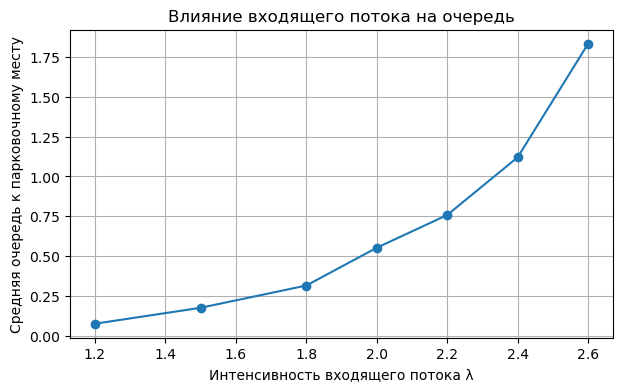

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(lambda_df["lambda"], lambda_df["avg_parking_queue"], marker="o")
plt.xlabel("Интенсивность входящего потока λ")
plt.ylabel("Средняя очередь к парковочному месту")
plt.title("Влияние входящего потока на очередь")
plt.grid(True)
plt.show()